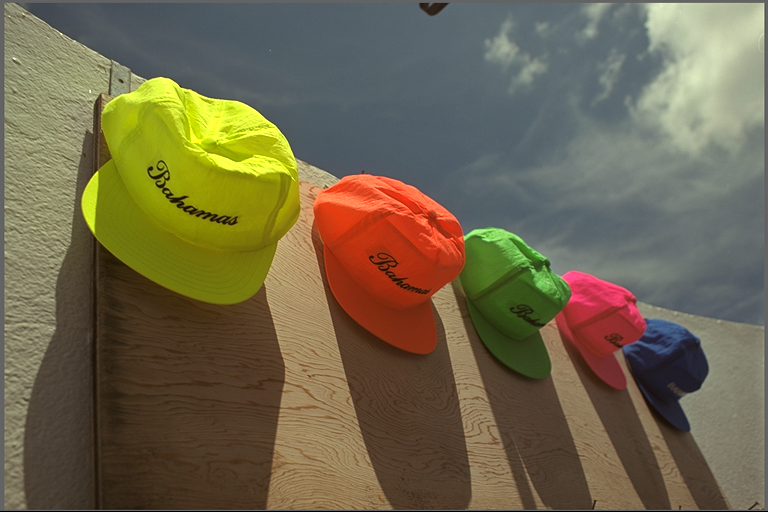

In [44]:
from PIL import Image
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/Suraiyaaurthi07/KMC/main/kodim03.png"

img = Image.open(BytesIO(requests.get(url).content))
img

In [45]:
!git clone https://github.com/Suraiyaaurthi07/KMC.git

fatal: destination path 'KMC' already exists and is not an empty directory.


(np.float64(-0.5), np.float64(767.5), np.float64(511.5), np.float64(-0.5))

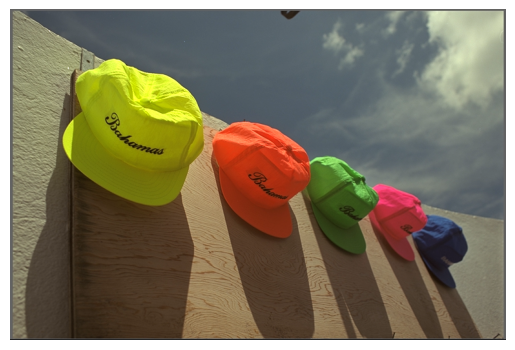

In [46]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("KMC/kodim03.png")
plt.imshow(img)
plt.axis('off')


In [47]:
import numpy as np
train_img = np.array(img)
print(train_img.shape)

(512, 768, 3)


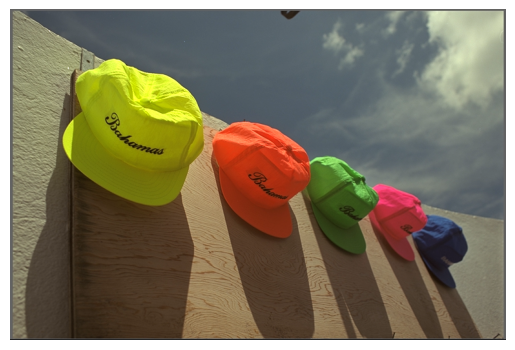

In [48]:
plt.imshow(train_img)
plt.axis("off")
plt.show()

In [49]:
pixels = train_img.reshape(-1, 3)

print(pixels.shape)

(393216, 3)


In [50]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

pixels_scaled = scaler.fit_transform(pixels)

In [51]:
from sklearn.cluster import KMeans
wcss = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(pixels_scaled)
    wcss.append(kmeans.inertia_)

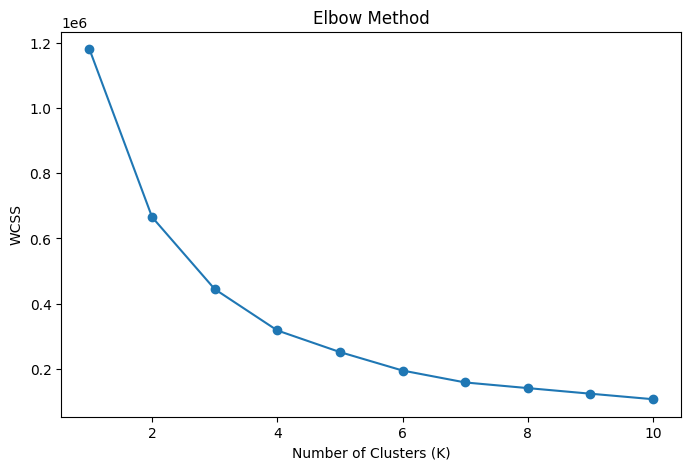

In [52]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [53]:
K = 8

In [54]:
kmeans = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

kmeans.fit(pixels_scaled)

KMeans(n_init=10, random_state=42)

In [55]:
import joblib

joblib.dump(kmeans, "color_quantizer.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [56]:
from google.colab import files
files.download("color_quantizer.pkl")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [57]:
!rm -rf KMC
!git clone https://github.com/Suraiyaaurthi07/KMC.git

Cloning into 'KMC'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 543.54 KiB | 5.23 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [58]:
!ls KMC


color_quantizer.pkl  custom_img.jpeg  kodim03.png  scaler.pkl


In [59]:
custom = Image.open(
    "KMC/custom_img.jpeg"
).convert("RGB")

custom_img = np.array(custom)

print(custom_img.shape)

(300, 450, 3)


In [60]:
custom_pixels = custom_img.reshape(-1, 3)

In [61]:
import joblib

kmeans = joblib.load("color_quantizer.pkl")
scaler = joblib.load("scaler.pkl")

In [62]:
custom_scaled = scaler.transform(custom_pixels)

In [64]:
labels = kmeans.predict(custom_scaled)

In [65]:
centers_scaled = kmeans.cluster_centers_
centers_scaled

array([[ 0.62877676,  0.66567697,  0.67862853],
       [-0.72385634, -0.91067384, -0.8079287 ],
       [-0.48383788, -0.04481843,  0.66512063],
       [ 0.51528848,  0.82129437, -1.53163886],
       [ 1.57672868, -1.05809413, -1.01694393],
       [ 2.55406355,  3.07619457, -0.5501438 ],
       [ 1.64268099,  1.75102399,  1.66026808],
       [-1.34655638, -1.34849428, -1.20959713]])

In [66]:
centers_rgb = scaler.inverse_transform(
    centers_scaled
)

In [82]:
quantized_pixels = centers_rgb[labels]

quantized_pixels = np.clip(
    quantized_pixels,
    0,255
).astype("uint8")

In [83]:
quantized_image = quantized_pixels.reshape(
    custom_img.shape
)

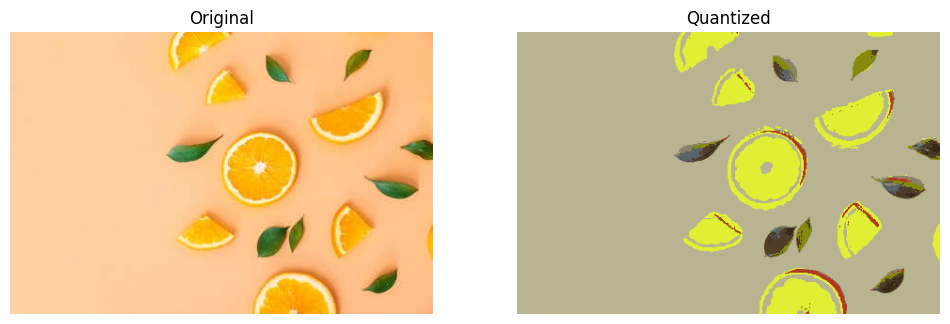

In [70]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(custom_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(quantized_image)
plt.title("Quantized")
plt.axis("off")

plt.show()

In [71]:
labels = kmeans.predict(custom_scaled)
labels

array([6, 6, 6, ..., 6, 6, 6], dtype=int32)

In [72]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt


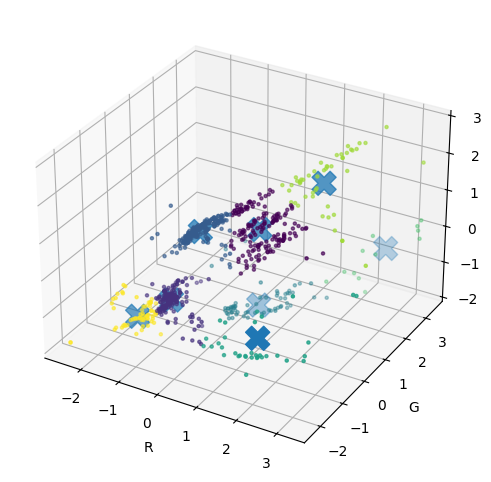

In [78]:
sample_pixels = pixels_scaled[::500]
sample_labels = kmeans.predict(sample_pixels)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    sample_pixels[:,0],
    sample_pixels[:,1],
    sample_pixels[:,2],
    c=sample_labels,
    s=5
)
centers = kmeans.cluster_centers_
ax.scatter(
    centers[:,0],
    centers[:,1],
    centers[:,2],
    marker='X',
    s=300
)

ax.set_xlabel('R')
ax.set_ylabel('G')
ax.set_zlabel('B')

plt.show()

In [79]:
import pandas as pd

In [80]:
sample_pixels = custom_pixels[:10]

sample_scaled = scaler.transform(sample_pixels)

sample_clusters = kmeans.predict(sample_scaled)

results = pd.DataFrame(
    sample_pixels,
    columns=["R","G","B"]
)

results["Cluster_ID"] = sample_clusters

results

,R,G,B,Cluster_ID
0,253,205,159,6
1,253,205,159,6
2,254,206,160,6
3,254,206,160,6
4,255,207,161,6
5,255,208,162,6
6,255,209,163,6
7,255,209,163,6
8,255,207,161,6
9,255,207,161,6


In [81]:
centroids_rgb = scaler.inverse_transform(
    kmeans.cluster_centers_
)
print(centroids_rgb.astype(int))

[[139 131 104]
 [ 79  61  41]
 [ 90  99 104]
 [134 138  10]
 [181  54  32]
 [224 239  52]
 [184 180 146]
 [ 52  41  24]]
